In [52]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [53]:
!wget -q https://zenodo.org/records/10715190/files/Carinthia_SEM_Defect_Dataset.zip -O /content/carinthia.zip

print("Download completed.")

Download completed.


In [54]:
import os

file_path = "/content/carinthia.zip"

if os.path.exists(file_path):
    print("File found!")
    print("File size:", os.path.getsize(file_path) / (1024 * 1024), "MB")
else:
    print("File NOT found.")

File found!
File size: 0.0 MB


In [32]:
!wget -q https://zenodo.org/records/10715190/files/data.zip -O /content/carinthia_data.zip

import os

print("File exists:", os.path.exists("/content/carinthia_data.zip"))
print("File size:", os.path.getsize("/content/carinthia_data.zip") / (1024 * 1024), "MB")

File exists: True
File size: 127.64060020446777 MB


In [33]:
import zipfile
import os

zip_path = "/content/carinthia_data.zip"
extract_path = "/content/carinthia_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Top-level contents:")
print(os.listdir(extract_path))

Dataset extracted successfully!
Top-level contents:
['data']


In [34]:
import os

data_path = "/content/carinthia_dataset/data"

print("Contents of data folder:")
print(os.listdir(data_path))

print("\nFolder structure:")
for root, dirs, files in os.walk(data_path):
    level = root.replace(data_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

    for file in files[:5]:
        print(f"{indent}  {file}")

Contents of data folder:
['carinthia.csv', 'images']

Folder structure:
data/
  carinthia.csv
  images/
    ce828ad169a042d3b951c8a92d998373.jpg
    f68575cc90394f98a888f66bf93fdf93.jpg
    157e4034a9804d349b2bb360076e61e7.jpg
    5f8b5a183ed3492cb81d3734cd47c29c.jpg
    f9a5bf8e41d24db4907581ff1948b4db.jpg


In [35]:
import pandas as pd

csv_path = "/content/carinthia_dataset/data/carinthia.csv"

df = pd.read_csv(
    csv_path,
    sep=";"
)

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (4591, 3)

Column names:
['image_path', 'file_name', 'label']

Class distribution:
label
3    4008
4     289
6     227
1      55
2       8
5       4
Name: count, dtype: int64

First 5 rows:


,image_path,file_name,label
0,data/images/2661734b21874fdf9e35a4319a9e7462.jpg,2661734b21874fdf9e35a4319a9e7462.jpg,6
1,data/images/0c8af9b8e62f4cb498392e806236e5e0.jpg,0c8af9b8e62f4cb498392e806236e5e0.jpg,6
2,data/images/ecb33a23f90b47fe8ee1dfe3e4d5f0df.jpg,ecb33a23f90b47fe8ee1dfe3e4d5f0df.jpg,6
3,data/images/adc88a3f9fb34ae79142ba9f12a6f1e1.jpg,adc88a3f9fb34ae79142ba9f12a6f1e1.jpg,6
4,data/images/bc228459f662459f80fbce99bedd9d20.jpg,bc228459f662459f80fbce99bedd9d20.jpg,6


In [36]:
print("Columns:")
print(df.columns.tolist())

print("\nNumber of classes:")
print(df["label"].nunique())

print("\nUnique labels:")
print(sorted(df["label"].unique()))

print("\nImages per class:")
print(df["label"].value_counts().sort_index())

Columns:
['image_path', 'file_name', 'label']

Number of classes:
6

Unique labels:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Images per class:
label
1      55
2       8
3    4008
4     289
5       4
6     227
Name: count, dtype: int64


In [37]:
import os

# Search for the dataset documentation
for root, dirs, files in os.walk("/content/carinthia_dataset"):
    for file in files:
        if file.lower().endswith((".html", ".htm", ".txt")):
            print(os.path.join(root, file))

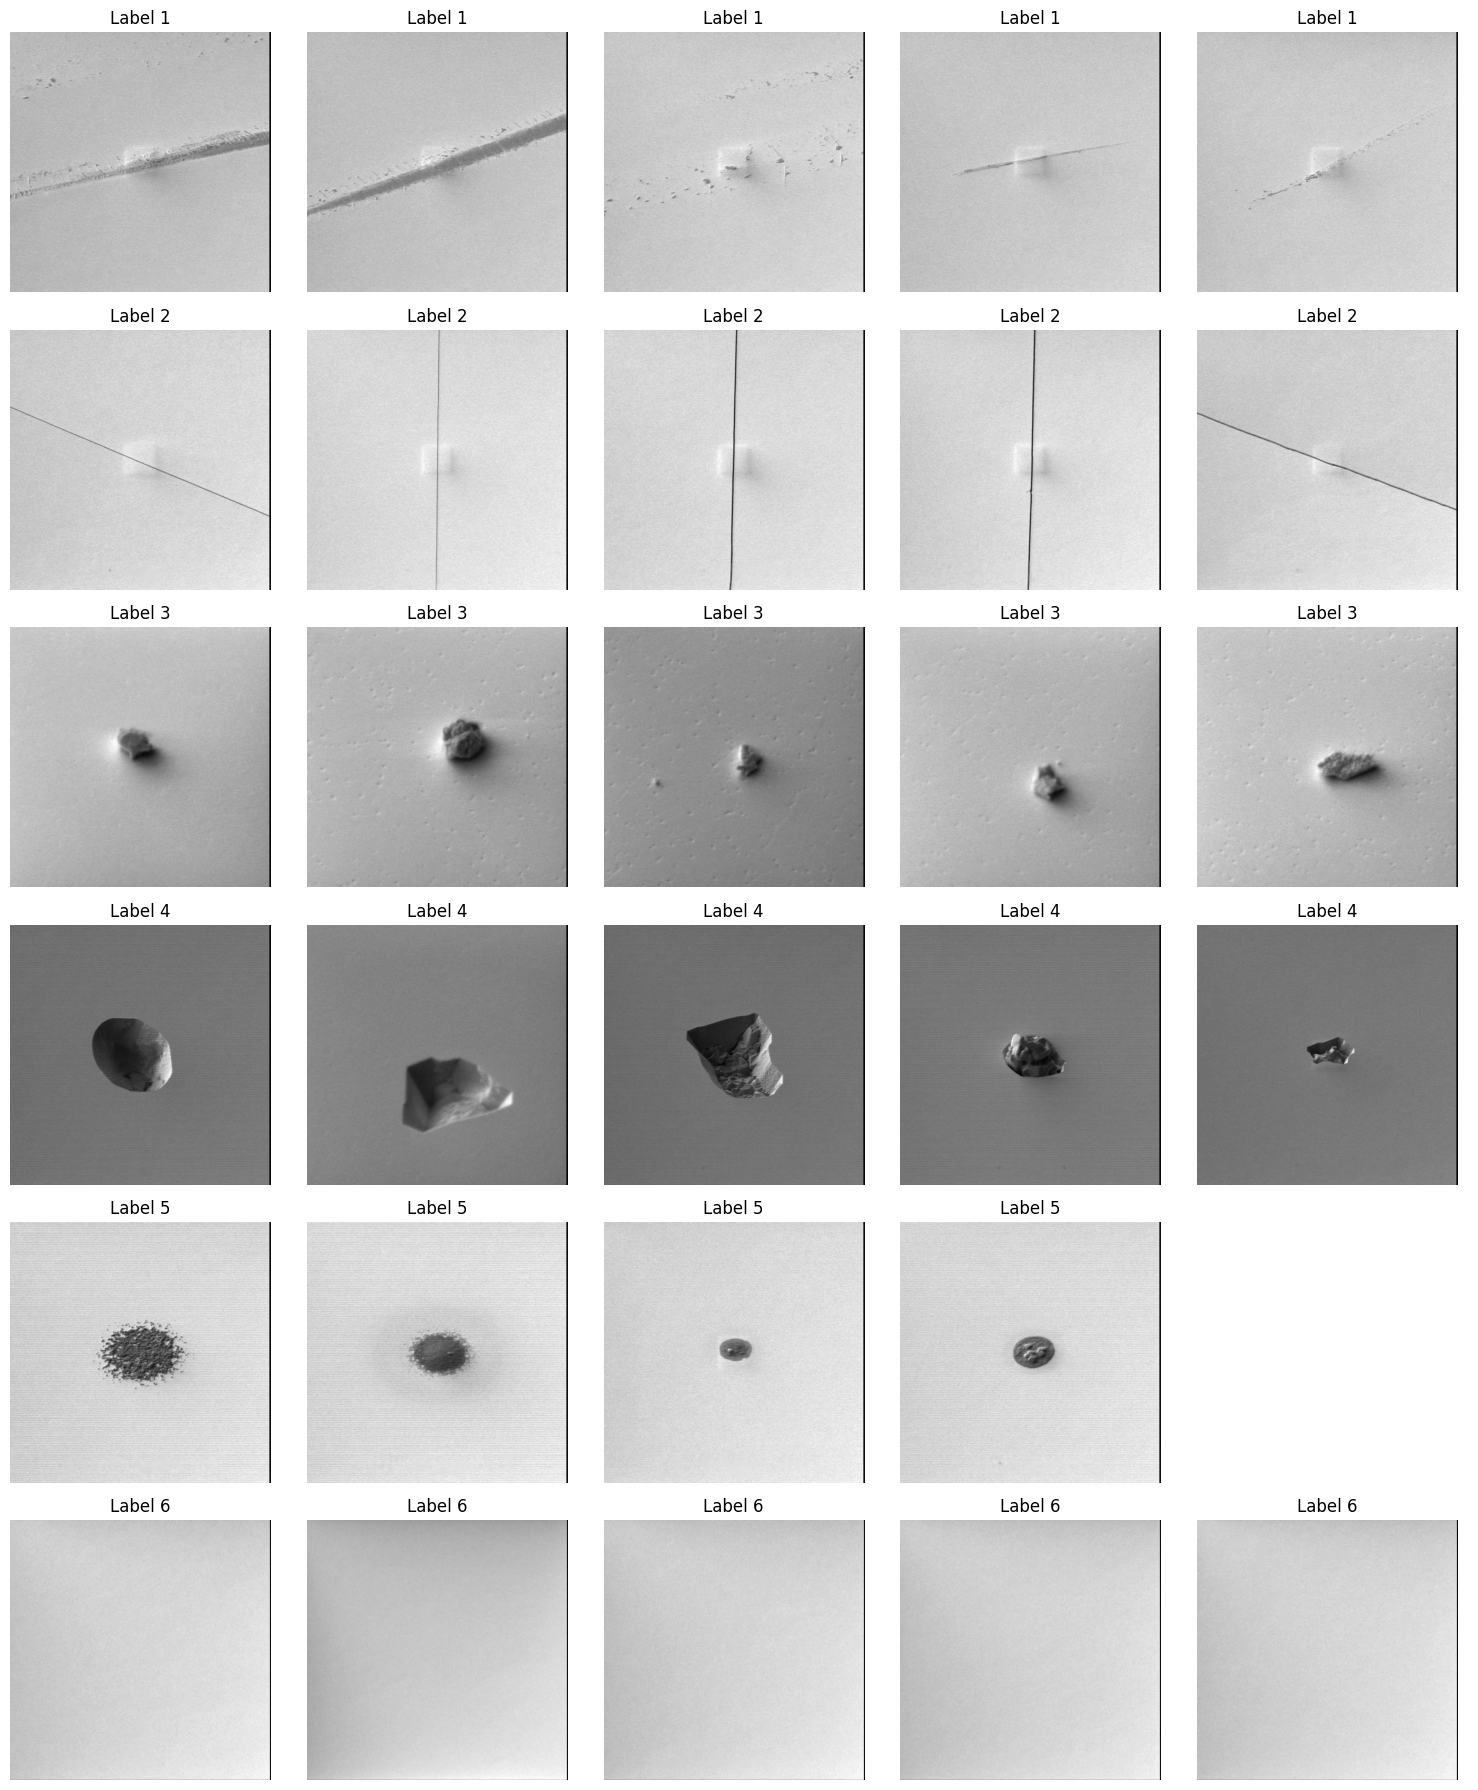

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import os

class_samples = {}

for label in sorted(df["label"].unique()):
    rows = df[df["label"] == label]
    samples = rows.sample(min(5, len(rows)), random_state=42)
    class_samples[label] = samples

fig, axes = plt.subplots(6, 5, figsize=(15, 18))

for row, label in enumerate(sorted(class_samples.keys())):
    for col in range(5):
        ax = axes[row, col]

        if col < len(class_samples[label]):
            sample = class_samples[label].iloc[col]

            img_path = "/content/carinthia_dataset/" + sample["image_path"]

            img = plt.imread(img_path)

            ax.imshow(img, cmap="gray")
            ax.set_title(f"Label {label}")

        ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
# Keep the 4 useful classes for our first prototype

selected_labels = [1, 3, 4, 6]

df_model = df[df["label"].isin(selected_labels)].copy()

print("Selected classes:")
print(df_model["label"].value_counts().sort_index())

print("\nTotal images:", len(df_model))

Selected classes:
label
1      55
3    4008
4     289
6     227
Name: count, dtype: int64

Total images: 4579


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Create train/validation split
train_df, val_df = train_test_split(
    df_model,
    test_size=0.20,
    random_state=42,
    stratify=df_model["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

# Calculate class weights
classes = np.array(sorted(train_df["label"].unique()))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(classes, weights))

print("\nClass weights:")
print(class_weights)

Training images: 3663
Validation images: 916

Training distribution:
label
1      44
3    3206
4     231
6     182
Name: count, dtype: int64

Validation distribution:
label
1     11
3    802
4     58
6     45
Name: count, dtype: int64

Class weights:
{np.int64(1): np.float64(20.8125), np.int64(3): np.float64(0.2856363069245165), np.int64(4): np.float64(3.9642857142857144), np.int64(6): np.float64(5.031593406593407)}


In [41]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Convert labels:
# 1 → 0
# 3 → 1
# 4 → 2
# 6 → 3

label_map = {
    1: 0,
    3: 1,
    4: 2,
    6: 3
}

train_df = train_df.copy()
val_df = val_df.copy()

train_df["class_id"] = train_df["label"].map(label_map)
val_df["class_id"] = val_df["label"].map(label_map)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

# Create full image paths
train_paths = [
    "/content/carinthia_dataset/" + p
    for p in train_df["image_path"]
]

val_paths = [
    "/content/carinthia_dataset/" + p
    for p in val_df["image_path"]
]

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_df["class_id"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_df["class_id"].values)
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Image datasets created successfully.")

Image datasets created successfully.


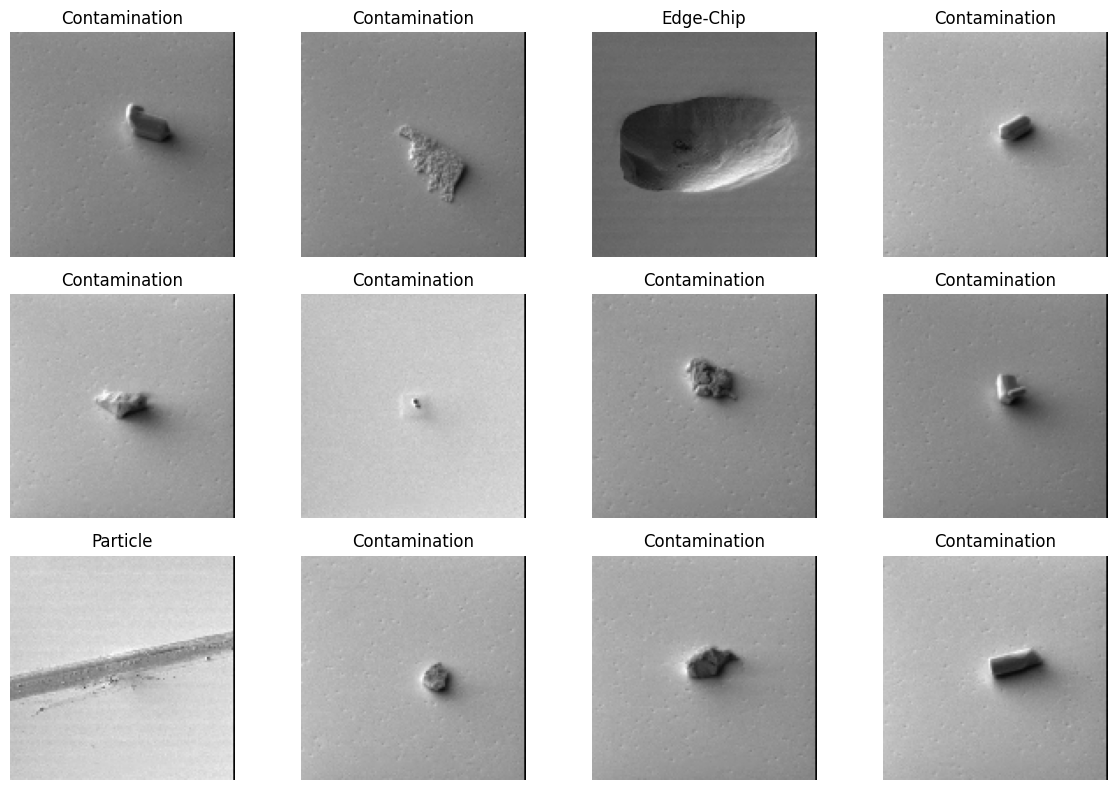

In [42]:
import matplotlib.pyplot as plt

class_names = [
    "Particle",
    "Contamination",
    "Edge-Chip",
    "Normal"
]

for images, labels in train_ds.take(1):

    plt.figure(figsize=(12, 8))

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        label = int(labels[i].numpy())
        plt.title(class_names[label])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [43]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128, 128, 1)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(4, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [44]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN compiled successfully.")

CNN compiled successfully.


In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight={
        0: class_weights[1],
        1: class_weights[3],
        2: class_weights[4],
        3: class_weights[6]
    },
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.6912 - loss: 0.8043 - val_accuracy: 0.0120 - val_loss: 1.4928 - learning_rate: 5.0000e-04
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8168 - loss: 0.6066 - val_accuracy: 0.0491 - val_loss: 2.0790 - learning_rate: 5.0000e-04
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8578 - loss: 0.4641 - val_accuracy: 0.0491 - val_loss: 2.3102 - learning_rate: 5.0000e-04
Epoch 4/30
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8737 - loss: 0.4091
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8709 - loss: 0.3916 - val_accuracy: 0.0491 - val_loss: 8.5654 - learning_rate: 5.0000e-04
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8821 - loss: 0.3274 - val_accuracy: 0.0535 - val_loss: 8.3546 - learning_rate: 2.5000e-04
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accurac

In [46]:
test_loss, test_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(f"\nValidation Accuracy: {test_accuracy * 100:.2f}%")
print(f"Validation Loss: {test_loss:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9116 - loss: 0.2466

Validation Accuracy: 91.16%
Validation Loss: 0.2466


Confusion Matrix:
[[ 10   1   0   0]
 [ 63 727  12   0]
 [  0   5  53   0]
 [  0   0   0  45]]

Classification Report:
               precision    recall  f1-score   support

     Particle     0.1370    0.9091    0.2381        11
Contamination     0.9918    0.9065    0.9472       802
    Edge-Chip     0.8154    0.9138    0.8618        58
       Normal     1.0000    1.0000    1.0000        45

     accuracy                         0.9116       916
    macro avg     0.7360    0.9323    0.7618       916
 weighted avg     0.9708    0.9116    0.9359       916



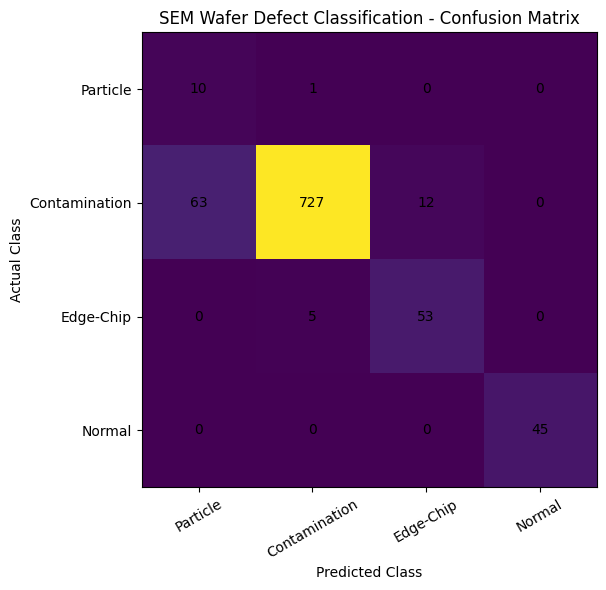

In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Get true labels
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

class_names = [
    "Particle",
    "Contamination",
    "Edge-Chip",
    "Normal"
]

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Plot confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("SEM Wafer Defect Classification - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(range(4), class_names, rotation=30)
plt.yticks(range(4), class_names)

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

Last convolutional layer: conv2d_5


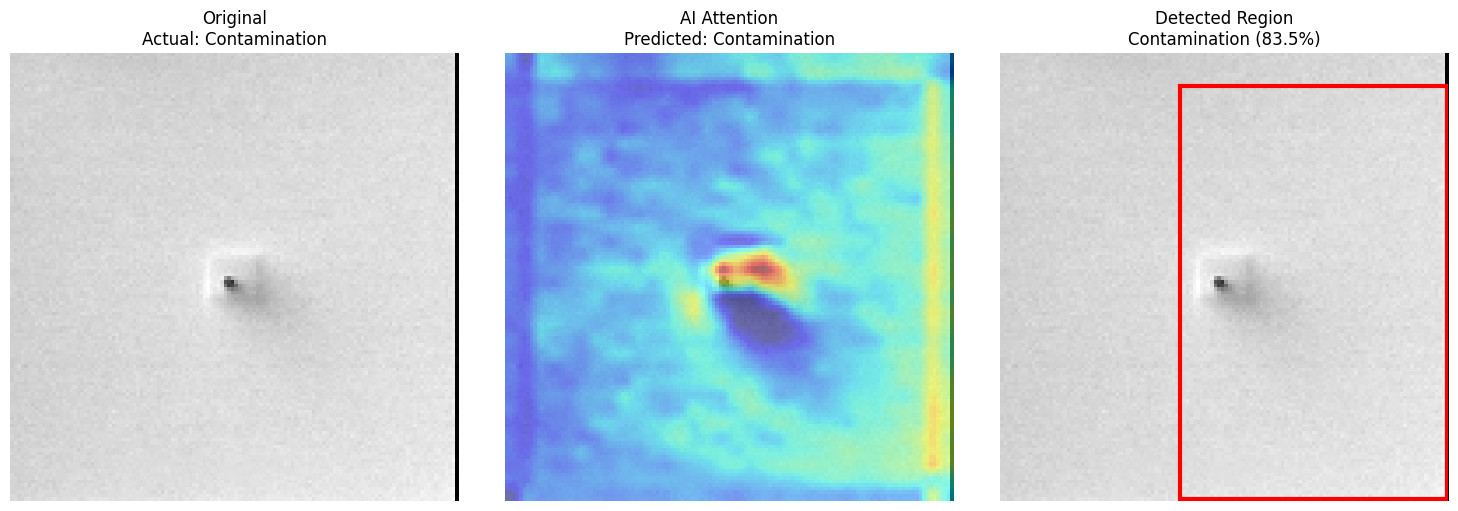

In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ------------------------------------------------
# Make sure the model has a concrete input/output
# ------------------------------------------------
dummy_input = tf.zeros((1, 128, 128, 1))
_ = model(dummy_input, training=False)

# Find the last convolutional layer
last_conv_layer = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Last convolutional layer:", last_conv_layer.name)

# Create Grad-CAM model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        last_conv_layer.output,
        model.outputs[0]
    ]
)

# ------------------------------------------------
# Take one validation image
# ------------------------------------------------
for images, labels in val_ds.take(1):

    image = images[0:1]
    true_label = int(labels[0].numpy())

    # Prediction
    prediction = model.predict(
        image,
        verbose=0
    )

    predicted_label = int(
        np.argmax(prediction[0])
    )

    confidence = float(
        prediction[0][predicted_label]
    )

    # ------------------------------------------------
    # Grad-CAM
    # ------------------------------------------------
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            image,
            training=False
        )

        class_score = predictions[:, predicted_label]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_gradients = pooled_gradients[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    heatmap = heatmap.numpy()

    # Resize heatmap
    heatmap = cv2.resize(
        heatmap,
        (128, 128)
    )

    # ------------------------------------------------
    # Original image
    # ------------------------------------------------
    original = image[0].numpy().squeeze()

    # Create mask
    mask = heatmap > 0.5

    ys, xs = np.where(mask)

    # ------------------------------------------------
    # Display
    # ------------------------------------------------
    plt.figure(figsize=(15, 5))

    # 1. Original
    plt.subplot(1, 3, 1)

    plt.imshow(
        original,
        cmap="gray"
    )

    plt.title(
        f"Original\n"
        f"Actual: {class_names[true_label]}"
    )

    plt.axis("off")

    # 2. Heatmap
    plt.subplot(1, 3, 2)

    plt.imshow(
        original,
        cmap="gray"
    )

    plt.imshow(
        heatmap,
        cmap="jet",
        alpha=0.5
    )

    plt.title(
        f"AI Attention\n"
        f"Predicted: {class_names[predicted_label]}"
    )

    plt.axis("off")

    # 3. Defect region
    plt.subplot(1, 3, 3)

    plt.imshow(
        original,
        cmap="gray"
    )

    if len(xs) > 0 and len(ys) > 0:

        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="red",
            linewidth=3
        )

        plt.gca().add_patch(rect)

    plt.title(
        f"Detected Region\n"
        f"{class_names[predicted_label]} "
        f"({confidence * 100:.1f}%)"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

In [49]:
# ============================================
# CORRECTIVE ACTION MODULE
# ============================================

corrective_actions = {
    "Particle": {
        "status": "DEFECT FOUND",
        "action": "Wafer cleaning / particle removal",
        "reason": "Foreign particles may affect wafer processing."
    },

    "Contamination": {
        "status": "DEFECT FOUND",
        "action": "Wafer cleaning + contamination source inspection",
        "reason": "Contamination can affect device fabrication quality."
    },

    "Edge-Chip": {
        "status": "DEFECT FOUND",
        "action": "Check wafer handling and edge-processing conditions",
        "reason": "Edge damage may occur during handling or processing."
    },

    "Normal": {
        "status": "NO DEFECT",
        "action": "No corrective action required",
        "reason": "No significant wafer defect detected."
    }
}

print("Corrective Action Module loaded successfully.")

Corrective Action Module loaded successfully.


In [50]:
# ============================================
# PREDICTION + CORRECTIVE ACTION
# ============================================

def inspect_wafer(image):

    # Resize image
    img = tf.image.resize(image, (128, 128))
    img = tf.cast(img, tf.float32)

    # Add channel dimension if required
    if len(img.shape) == 2:
        img = tf.expand_dims(img, axis=-1)

    # Add batch dimension
    img = tf.expand_dims(img, axis=0)

    # AI prediction
    prediction = model.predict(img, verbose=0)

    predicted_index = np.argmax(prediction[0])
    confidence = prediction[0][predicted_index]

    predicted_class = class_names[predicted_index]

    # Get corrective action
    result = corrective_actions[predicted_class]

    print("=" * 55)
    print("          AI WAFER INSPECTION RESULT")
    print("=" * 55)

    print(f"Defect Type        : {predicted_class}")
    print(f"Confidence         : {confidence * 100:.2f}%")
    print(f"Status             : {result['status']}")
    print(f"Recommended Action : {result['action']}")
    print(f"Reason             : {result['reason']}")

    print("=" * 55)

    return predicted_class, confidence

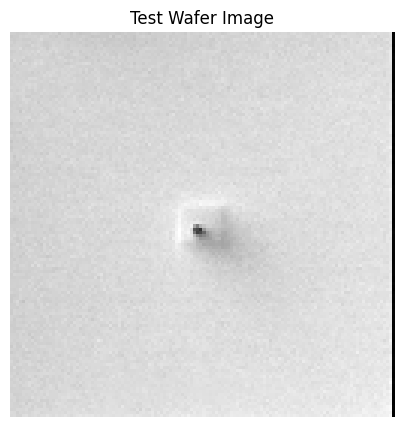

          AI WAFER INSPECTION RESULT
Defect Type        : Contamination
Confidence         : 83.51%
Status             : DEFECT FOUND
Recommended Action : Wafer cleaning + contamination source inspection
Reason             : Contamination can affect device fabrication quality.


In [51]:
# ============================================
# TEST THE AI WAFER INSPECTION
# ============================================

for images, labels in val_ds.take(1):

    test_image = images[0]

    # Display test image
    plt.figure(figsize=(5, 5))

    plt.imshow(
        test_image.numpy().squeeze(),
        cmap="gray"
    )

    plt.title("Test Wafer Image")
    plt.axis("off")
    plt.show()

    # Run AI inspection
    predicted_class, confidence = inspect_wafer(test_image)

    break